**CITS2402 - Introduction to Data Science - Project**

*Comparing Migration and Cultural Diversity in Australia and New Zealand*

**Census data analysis using the 2021 Australian Census and 2023 New Zealand Census**


**Declaration**

*I/we am/are aware of the University’s [policy on academic conduct](https://www.uwa.edu.au/policy/-/media/project/uwa/uwa/policy-library/policy/student-administration/academic-integrity/academic-integrity-policy.doc) and I declare that this assignment is entirely the work of the author(s) listed below and that suitable acknowledgement has been made for any sources of information used in preparing it. I have retained a copy for my own records.*

- Name 1: Tri Cuong Do
- Student ID 1: 24769627
- Name 2: Minh Hung Le
- Student ID 2: 24769322

# Introduction and Research Question

Australia and New Zealand both have large migrant populations and culturally diverse communities. This project compares the size, origins and settlement periods of their overseas-born populations. It then examines ethnicity, ancestry and languages to understand how migration background is related to cultural diversity.

**Research question:** How do migration patterns differ between Australia and New Zealand, and how are these patterns related to cultural diversity in the two countries?

The comparison is descriptive. Australia and New Zealand use different Census years and do not measure every cultural variable in exactly the same way.

# Data Sources and Preparation

## Australia

Australian data were downloaded from the [ABS 2021 Census DataPacks](https://www.abs.gov.au/census/find-census-data/datapacks). The selections were Census year **2021**, DataPack type **General Community Profile**, geography **Australia**, and the short-header CSV format.

The analysis uses:

- `G08` for ancestry and parents' birthplace by ancestry.
- `G09F-G09H` for country of birth.
- `G10C` for year of arrival totals.
- `G13C-G13E` for languages used at home.

## New Zealand

New Zealand data were downloaded from the [Stats NZ Aotearoa Data Explorer](https://explore.data.stats.govt.nz/). The selections used Census year **2023**, the national total area, and total age or gender categories where applicable.

The four downloaded files cover birthplace, years since arrival, ethnicity, and language by birthplace.

## Preparation and assumptions

The code reads the supplied CSV files without changing them. Category codes are converted to readable labels where required. Counts are converted to numeric values and percentages are calculated using a clearly stated denominator. The birthplace comparison excludes responses where birthplace was not stated. Ancestry, ethnicity and language can allow multiple responses, so percentages from those variables should not be added together.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the main Australian cultural-diversity table once for later sections.
aus_ancestry = pd.read_csv("2021Census_G08_AUS_AUS.csv")


# Migration Patterns

This section compares birthplace, major overseas birthplaces and broad settlement cohorts. For the first comparison, percentages use only people whose birthplace was stated so that the two parts add to 100%.

In [2]:
def load_australia_migration():
    # Load and prepare Australian birthplace and arrival data.
    g09_files = [
        "2021Census_G09F_AUS_AUS.csv",
        "2021Census_G09G_AUS_AUS.csv",
        "2021Census_G09H_AUS_AUS.csv",
    ]
    g09 = pd.concat([pd.read_csv(file) for file in g09_files], axis=1)
    g09 = g09.loc[:, ~g09.columns.duplicated()]

    # Extract total-person birthplace counts.
    total_columns = [
        column for column in g09.columns
        if column.startswith("P_") and column.endswith("_Tot")
    ]
    birthplace = pd.DataFrame({
        "Country": [column[2:-4].replace("_", " ") for column in total_columns],
        "Count": [pd.to_numeric(g09.loc[0, column]) for column in total_columns],
    })

    total_population = int(g09.loc[0, "P_Tot_Tot"])
    australia_born = int(g09.loc[0, "P_Australia_Tot"])
    not_stated = int(g09.loc[0, "P_COB_NS_Tot"])
    overseas_born = total_population - australia_born - not_stated

    # Remove totals and residual categories from the country ranking.
    excluded = ["Tot", "Australia", "COB NS", "Elsewhere"]
    overseas_countries = birthplace[
        ~birthplace["Country"].isin(excluded)
    ].copy()
    overseas_countries["Country"] = overseas_countries["Country"].replace({
        "Bosnia Herzegov": "Bosnia and Herzegovina",
        "Korea South": "South Korea",
        "Hong Kong SAR of Ch": "Hong Kong",
        "USA": "United States",
    })
    overseas_countries["Percentage"] = (
        overseas_countries["Count"] / total_population * 100
    )
    overseas_countries = overseas_countries.sort_values(
        "Count", ascending=False
    ).reset_index(drop=True)

    # G10C contains the national totals for each arrival period.
    g10 = pd.read_csv("2021Census_G10C_AUS_AUS.csv")
    long_term_columns = [
        "Tot_Before_1951", "Tot_1951_1960", "Tot_1961_1970",
        "Tot_1971_1980", "Tot_1981_1990", "Tot_1991_2000",
    ]
    recent_columns = [
        "Tot_2016", "Tot_2017", "Tot_2018",
        "Tot_2019", "Tot_2020", "Tot_2021",
    ]
    cohort_counts = [
        g10.loc[0, recent_columns].sum(),
        g10.loc[0, "Tot_2011_2015"],
        g10.loc[0, "Tot_2001_2010"],
        g10.loc[0, long_term_columns].sum(),
    ]
    cohort_total = sum(cohort_counts)
    cohorts = pd.DataFrame({
        "Cohort": [
            "Recent (< 5 yrs)", "Medium (5-9 yrs)",
            "Established (10-19 yrs)", "Long-term (>= 20 yrs)",
        ],
        "Count": cohort_counts,
    })
    cohorts["Percentage"] = cohorts["Count"] / cohort_total * 100

    return (
        total_population, australia_born, overseas_born,
        overseas_countries, cohorts,
    )


def load_new_zealand_migration():
    # Load and prepare New Zealand birthplace and arrival data.
    birthplace = pd.read_csv("NZ_Census2023_Birthplace.csv")
    birthplace["Count"] = pd.to_numeric(birthplace["OBS_VALUE"])

    total_population = int(
        birthplace.loc[birthplace["Birthplace"] == "Total - birthplace", "Count"].iloc[0]
    )
    new_zealand_born = int(
        birthplace.loc[birthplace["Birthplace"] == "New Zealand", "Count"].iloc[0]
    )
    overseas_born = int(
        birthplace.loc[birthplace["Birthplace"] == "Overseas", "Count"].iloc[0]
    )

    # Remove total and regional aggregate categories from the country ranking.
    excluded = {
        "Total - birthplace", "New Zealand", "Overseas",
        "Total stated - birthplace", "Not elsewhere included",
        "Pacific Islands", "North-West Europe", "Southern and Eastern Europe",
        "North Africa and the Middle East", "South-East Asia", "North-East Asia",
        "Southern and Central Asia", "The Americas", "Sub-Saharan Africa",
        "Oceania and Antarctica", "Other",
    }
    overseas_countries = birthplace[
        ~birthplace["Birthplace"].isin(excluded)
    ][["Birthplace", "Count"]].copy()
    overseas_countries = overseas_countries.rename(
        columns={"Birthplace": "Country"}
    )
    overseas_countries["Country"] = overseas_countries["Country"].replace({
        "China, People's Republic of": "China",
        "United States of America": "United States",
        "Korea, Republic of": "South Korea",
    })
    overseas_countries["Percentage"] = (
        overseas_countries["Count"] / total_population * 100
    )
    overseas_countries = overseas_countries.sort_values(
        "Count", ascending=False
    ).reset_index(drop=True)

    arrival = pd.read_csv("NZ_Census2023_YearsSinceArrival.csv")
    total_rows = arrival[arrival["Birthplace"] == "Total - birthplace"].copy()

    def arrival_count(label):
        return float(
            total_rows.loc[
                total_rows["Years since arrival in New Zealand"] == label,
                "OBS_VALUE",
            ].iloc[0]
        )

    cohort_counts = [
        sum(arrival_count(label) for label in [
            "Less than one year", "1 year", "2 years", "3 years", "4 years"
        ]),
        arrival_count("5-9 years"),
        arrival_count("10-19 years"),
        arrival_count("20 years or more"),
    ]
    cohort_total = sum(cohort_counts)
    cohorts = pd.DataFrame({
        "Cohort": [
            "Recent (< 5 yrs)", "Medium (5-9 yrs)",
            "Established (10-19 yrs)", "Long-term (>= 20 yrs)",
        ],
        "Count": cohort_counts,
    })
    cohorts["Percentage"] = cohorts["Count"] / cohort_total * 100

    return (
        total_population, new_zealand_born, overseas_born,
        overseas_countries, cohorts,
    )


(
    au_total, au_born_in_country, au_born_overseas,
    au_birthplace_ranking, au_arrival_cohorts,
) = load_australia_migration()

(
    nz_total, nz_born_in_country, nz_born_overseas,
    nz_birthplace_ranking, nz_arrival_cohorts,
) = load_new_zealand_migration()

print("Australia overseas-born:", f"{au_born_overseas:,}")
print("New Zealand overseas-born:", f"{nz_born_overseas:,}")


Australia overseas-born: 7,043,708
New Zealand overseas-born: 1,426,983


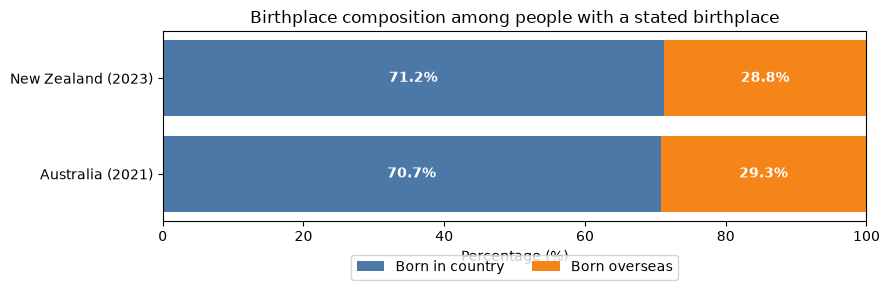

In [3]:
# Figure 1: birthplace composition among people with a stated birthplace
labels = ["Australia (2021)", "New Zealand (2023)"]
born_in_country = [
    au_born_in_country / (au_born_in_country + au_born_overseas) * 100,
    nz_born_in_country / (nz_born_in_country + nz_born_overseas) * 100,
]
born_overseas = [
    au_born_overseas / (au_born_in_country + au_born_overseas) * 100,
    nz_born_overseas / (nz_born_in_country + nz_born_overseas) * 100,
]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(labels, born_in_country, label="Born in country", color="#4C78A8")
ax.barh(
    labels, born_overseas, left=born_in_country,
    label="Born overseas", color="#F58518"
)
for index in range(len(labels)):
    ax.text(
        born_in_country[index] / 2, index,
        f"{born_in_country[index]:.1f}%",
        ha="center", va="center", color="white", fontweight="bold"
    )
    ax.text(
        born_in_country[index] + born_overseas[index] / 2, index,
        f"{born_overseas[index]:.1f}%",
        ha="center", va="center", color="white", fontweight="bold"
    )
ax.set_title("Birthplace composition among people with a stated birthplace")
ax.set_xlabel("Percentage (%)")
ax.set_xlim(0, 100)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()


## Interpretation

The two countries had similar birthplace profiles. Among people whose birthplace was stated, 29.3% were born overseas in Australia and 28.8% were born overseas in New Zealand. This measure describes birthplace only and does not show citizenship or the reason for migration.

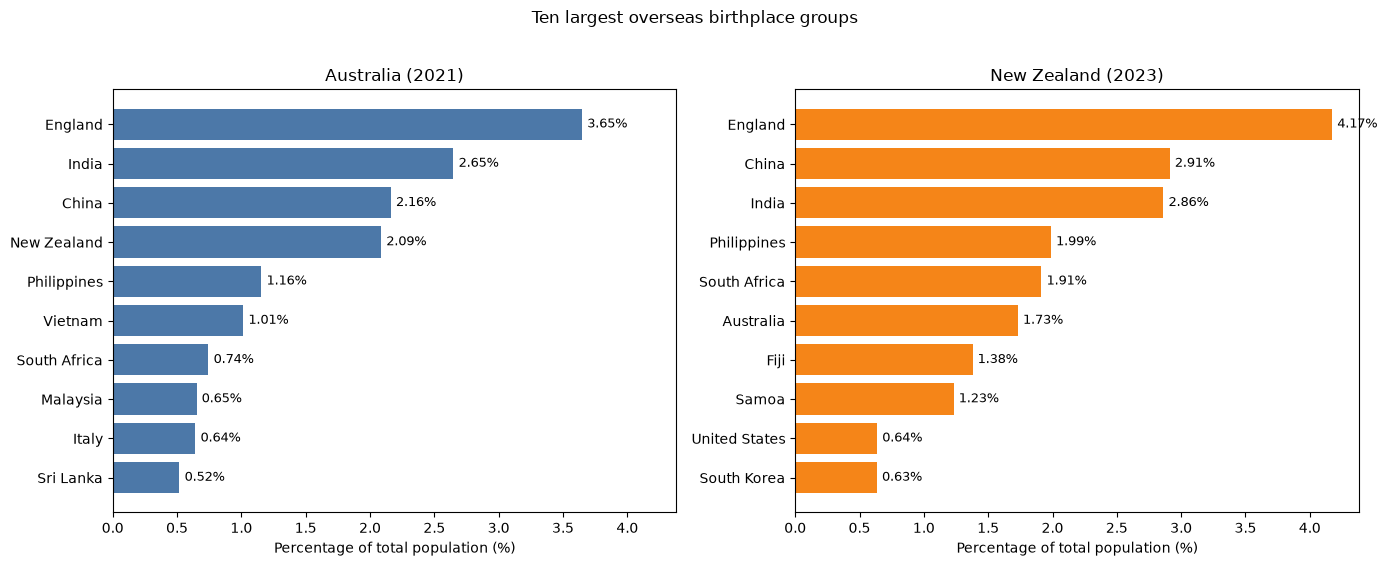

In [4]:
# Figure 2: ten largest overseas birthplace groups in each country
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)

for axis, data, title, colour in [
    (axes[0], au_birthplace_ranking.head(10).iloc[::-1],
     "Australia (2021)", "#4C78A8"),
    (axes[1], nz_birthplace_ranking.head(10).iloc[::-1],
     "New Zealand (2023)", "#F58518"),
]:
    axis.barh(data["Country"], data["Percentage"], color=colour)
    axis.set_title(title)
    axis.set_xlabel("Percentage of total population (%)")
    for index, value in enumerate(data["Percentage"]):
        axis.text(value + 0.04, index, f"{value:.2f}%", va="center", fontsize=9)

fig.suptitle("Ten largest overseas birthplace groups", y=1.02)
plt.tight_layout()
plt.show()


## Interpretation

England was the largest overseas birthplace in both countries, accounting for 3.65% of Australia's population and 4.17% of New Zealand's population. India and China were also among the three largest groups in both countries. New Zealand had Fiji and Samoa in its top ten, while Australia had Vietnam and Malaysia. New Zealand was Australia's fourth-largest overseas birthplace, while Australia was New Zealand's sixth-largest.

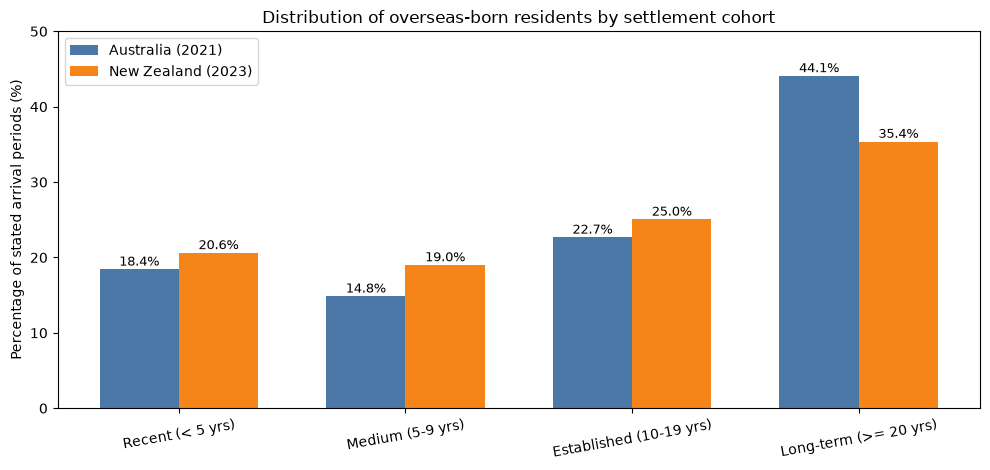

In [5]:
# Figure 3: broad settlement cohorts among people with a stated arrival period
x = np.arange(len(au_arrival_cohorts))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4.8))

bars_au = ax.bar(
    x - width / 2, au_arrival_cohorts["Percentage"], width,
    label="Australia (2021)", color="#4C78A8"
)
bars_nz = ax.bar(
    x + width / 2, nz_arrival_cohorts["Percentage"], width,
    label="New Zealand (2023)", color="#F58518"
)
ax.set_title("Distribution of overseas-born residents by settlement cohort")
ax.set_ylabel("Percentage of stated arrival periods (%)")
ax.set_xticks(x)
ax.set_xticklabels(au_arrival_cohorts["Cohort"], rotation=10)
ax.legend()
for bars in [bars_au, bars_nz]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", fontsize=9,
        )
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()


## Interpretation

Long-term residents formed the largest settlement cohort in both countries. They represented 44.1% of the stated arrival periods in Australia and 35.4% in New Zealand. New Zealand had larger shares in the recent, medium and established cohorts. The Census years are different, so the chart describes each country at a different point in time.

# Cultural Diversity

This section uses ethnicity and languages spoken for New Zealand, and ancestry and language used at home for Australia. These variables are related but not identical, so the comparisons are descriptive.

## Ethnicity in New Zealand

The New Zealand Census allows respondents to identify with more than one ethnic group. The percentages may therefore add to more than 100%.

In [6]:
# Read only the columns required for the analysis
# Codes are read as strings so values such as "01" are preserved

nz_ethnicity_raw = pd.read_csv(
    "NZ_ethnicity.csv",
    usecols=[
        "CEN23_YEAR_001",
        "CEN23_GEO_002",
        "CEN23_LAN_001",
        "CEN23_BIR_007",
        "CEN23_ETH_002",
        "OBS_VALUE"
    ],
    dtype={
        "CEN23_YEAR_001": "string",
        "CEN23_GEO_002": "string",
        "CEN23_LAN_001": "string",
        "CEN23_BIR_007": "string",
        "CEN23_ETH_002": "string"
    }
)
# Map official Stats NZ ethnicity codes to readable labels
ethnicity_labels = {
    "999": "Total ethnicity",
    "1": "European",
    "2": "Māori",
    "3": "Pacific Peoples",
    "4": "Asian",
    "5": "Middle Eastern/Latin American/African",
    "61": "New Zealander",
    "69": "Other ethnicity",
    "777": "Total stated",
    "9": "Not elsewhere included"
}

nz_ethnicity_raw["Ethnicity"] = (
    nz_ethnicity_raw["CEN23_ETH_002"].map(ethnicity_labels)
)

nz_ethnicity_raw["OBS_VALUE"] = pd.to_numeric(
    nz_ethnicity_raw["OBS_VALUE"]
)

nz_ethnicity_raw[
    ["CEN23_ETH_002", "Ethnicity", "OBS_VALUE"]
].sort_values("OBS_VALUE", ascending=False)


,CEN23_ETH_002,Ethnicity,OBS_VALUE
4,999,Total ethnicity,4993923
5,777,Total stated,4993923
8,1,European,3383742
9,2,Māori,887493
0,4,Asian,861576
1,3,Pacific Peoples,442632
3,5,Middle Eastern/Latin American/African,92760
6,61,New Zealander,42684
7,69,Other ethnicity,13506
2,9,Not elsewhere included,0


In [7]:
# Check the number of rows, missing values and duplicate ethnicity codes
print("Number of rows:", len(nz_ethnicity_raw))
print("Missing counts:", nz_ethnicity_raw["OBS_VALUE"].isna().sum())
print(
    "Duplicate ethnicity codes:",
    nz_ethnicity_raw["CEN23_ETH_002"].duplicated().sum()
)

assert len(nz_ethnicity_raw) == 10
assert nz_ethnicity_raw["OBS_VALUE"].isna().sum() == 0
assert nz_ethnicity_raw["CEN23_ETH_002"].duplicated().sum() == 0


Number of rows: 10
Missing counts: 0
Duplicate ethnicity codes: 0


In [8]:
# Use New Zealand total population as the denominator to calculate the percentage
total_nz_population = nz_ethnicity_raw.loc[
    nz_ethnicity_raw["CEN23_ETH_002"] == "999",
    "OBS_VALUE"
].iloc[0]

ethnicity_codes = ["1", "2", "3", "4", "5", "61", "69"]

nz_ethnicity_analysis = (
    nz_ethnicity_raw[
        nz_ethnicity_raw["CEN23_ETH_002"].isin(ethnicity_codes)
    ][["Ethnicity", "OBS_VALUE"]]
    .copy()
)

nz_ethnicity_analysis["Percentage"] = (
    nz_ethnicity_analysis["OBS_VALUE"]
    / total_nz_population
    * 100
)

nz_ethnicity_analysis = nz_ethnicity_analysis.sort_values(
    "Percentage",
    ascending=False
)


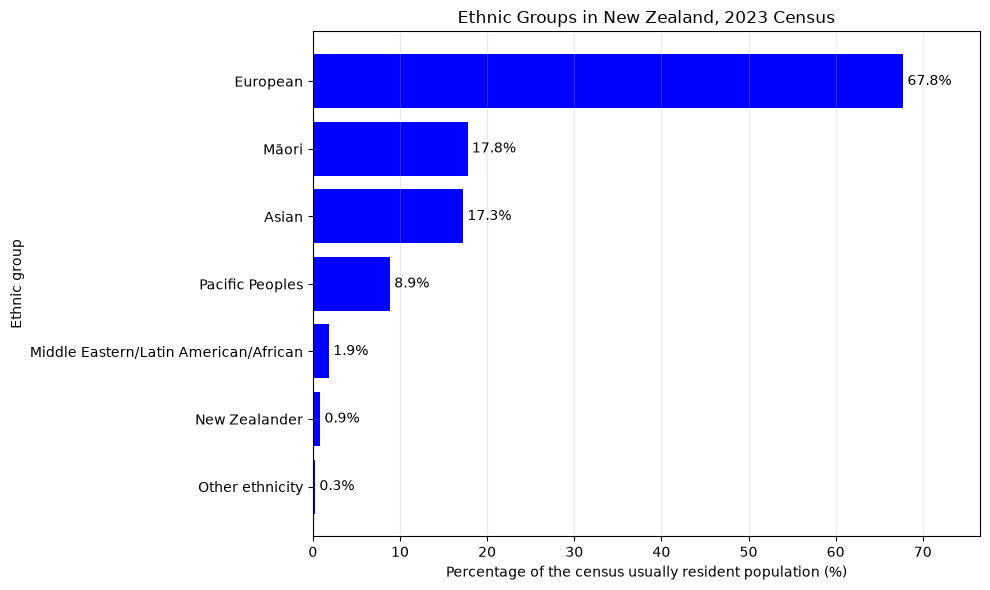

In [9]:
# Plot the ethnicity percentages from smallest to largest
plot_data = nz_ethnicity_analysis.sort_values("Percentage")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_data["Ethnicity"],
    plot_data["Percentage"],
    color= 'blue'
)

ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in plot_data["Percentage"]],
    padding=3
)

ax.set_title(
    "Ethnic Groups in New Zealand, 2023 Census"
)
ax.set_xlabel(
    "Percentage of the census usually resident population (%)"
)
ax.set_ylabel("Ethnic group")
ax.set_xlim(0, plot_data["Percentage"].max() * 1.13)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


## Interpretation

European was the largest ethnic group in New Zealand in the 2023 Census, making up 67.8% of the population. Māori and Asian groups had similar percentages, at 17.8% and 17.3%. Pacific Peoples made up 8.9%.

This shows that New Zealand has people from different cultural backgrounds. The ethnicity and language results both help us understand cultural diversity in the country.

**Note:** People could select more than one ethnicity in the Census. Therefore, the percentages may add up to more than 100%.

## Languages Spoken in New Zealand

In [10]:
# Load the variables needed for the language and birthplace analysis
nz_language_raw = pd.read_csv(
    "NZ_language_birthplace.csv",
    usecols=[
        "CEN23_YEAR_001",
        "CEN23_GEO_002",
        "CEN23_LAN_001",
        "CEN23_BIR_007",
        "CEN23_ETH_002",
        "OBS_VALUE"
    ],
    dtype={
        "CEN23_YEAR_001": "string",
        "CEN23_GEO_002": "string",
        "CEN23_LAN_001": "string",
        "CEN23_BIR_007": "string",
        "CEN23_ETH_002": "string"
    }
)

# Convert the official Stats NZ category codes into readable labels
language_labels = {
    "999": "Total languages spoken",
    "01": "English",
    "02": "Māori",
    "03": "Samoan",
    "04": "Northern Chinese",
    "05": "Hindi",
    "06": "French",
    "07": "Yue",
    "08": "Sinitic not further defined",
    "09": "Tagalog",
    "10": "German",
    "11": "Spanish",
    "12": "Afrikaans",
    "13": "Tongan",
    "14": "Panjabi",
    "15": "New Zealand Sign Language",
    "16": "Other",
    "17": "None (for example, too young to talk)",
    "777": "Total stated",
    "99": "Not elsewhere included"
}

birthplace_labels = {
    "99": "Total birthplace",
    "0": "NZ born",
    "1": "Overseas born",
    "77": "Total stated",
    "9": "Not elsewhere included"
}

nz_language_raw["Language"] = (
    nz_language_raw["CEN23_LAN_001"].map(language_labels)
)

nz_language_raw["Birthplace"] = (
    nz_language_raw["CEN23_BIR_007"].map(birthplace_labels)
)

nz_language_raw["OBS_VALUE"] = pd.to_numeric(
    nz_language_raw["OBS_VALUE"]
)


In [11]:
# Check the expected number of rows, categories and missing values
print("Rows:", len(nz_language_raw))
print(
    "Language categories:",
    nz_language_raw["CEN23_LAN_001"].nunique()
)
print(
    "Birthplace categories:",
    nz_language_raw["CEN23_BIR_007"].nunique()
)
print("Missing counts:", nz_language_raw["OBS_VALUE"].isna().sum())

assert len(nz_language_raw) == 100
assert nz_language_raw["CEN23_LAN_001"].nunique() == 20
assert nz_language_raw["CEN23_BIR_007"].nunique() == 5
assert nz_language_raw["OBS_VALUE"].isna().sum() == 0


Rows: 100
Language categories: 20
Birthplace categories: 5
Missing counts: 0


In [12]:
# Use the total Census population as the percentage denominator
total_nz_population = nz_language_raw.loc[
    (nz_language_raw["CEN23_LAN_001"] == "999")
    & (nz_language_raw["CEN23_BIR_007"] == "99"),
    "OBS_VALUE"
].iloc[0]

# Select named languages but exclude English, Other, None and total rows.
language_codes = [
    f"{code:02d}" for code in range(2, 16)
]

nz_language_profile = (
    nz_language_raw[
        (nz_language_raw["CEN23_BIR_007"] == "99")
        & (nz_language_raw["CEN23_LAN_001"].isin(language_codes))
    ][["Language", "OBS_VALUE"]]
    .copy()
)

nz_language_profile["Percentage"] = (
    nz_language_profile["OBS_VALUE"]
    / total_nz_population
    * 100
)

nz_language_profile = nz_language_profile.sort_values(
    "Percentage",
    ascending=False
)


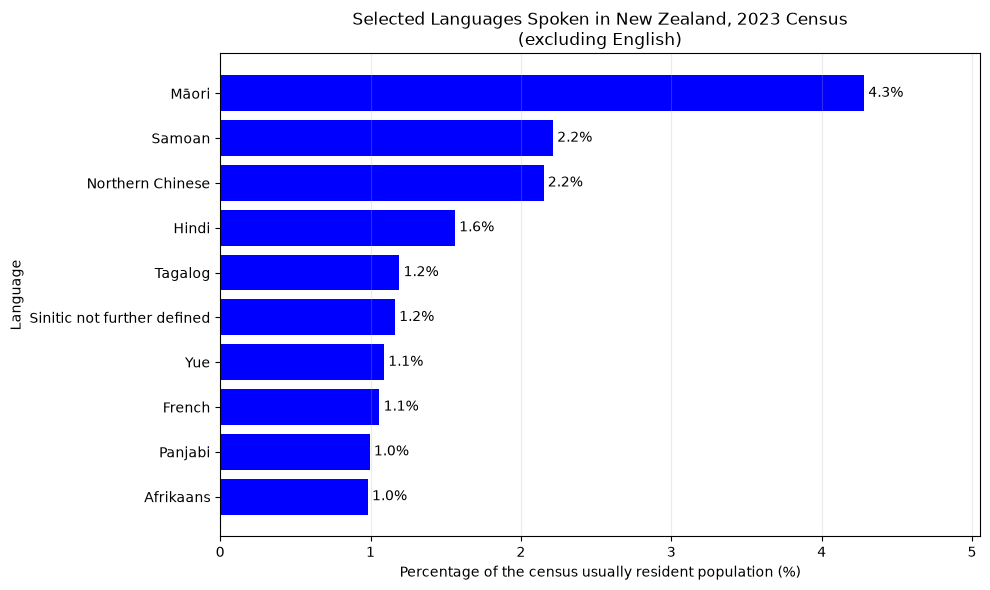

In [13]:
# Plot ten largest selected non-English language categories
top_languages = (
    nz_language_profile
    .head(10)
    .sort_values("Percentage")
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_languages["Language"],
    top_languages["Percentage"],
    color= 'blue'
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in top_languages["Percentage"]
    ],
    padding=3
)

ax.set_title(
    "Selected Languages Spoken in New Zealand, 2023 Census\n"
    "(excluding English)"
)
ax.set_xlabel(
    "Percentage of the census usually resident population (%)"
)
ax.set_ylabel("Language")
ax.set_xlim(0, top_languages["Percentage"].max() * 1.18)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


## Interpretation

Among the selected languages other than English, Māori was the most commonly spoken language, at 4.3% of the New Zealand population. Samoan and Northern Chinese were next, both at 2.2%, followed by Hindi at 1.6%.

The results show that several Indigenous, Pacific and Asian languages are spoken in New Zealand. This suggests that language is an important part of the country's cultural diversity.

**Note:** People could report more than one language. Therefore, the percentages should not be added together.

## Ancestry in Australia

The Australian Census allows respondents to report more than one ancestry. The percentages may therefore add to more than 100%.

In [14]:
# Main ancestry variables in the Australian Census dataset
ancestry_columns = {
    "English": "English_Tot_resp",
    "Australian": "Aust_Tot_resp",
    "Irish": "Irish_Tot_resp",
    "Scottish": "Scottish_Tot_resp",
    "Chinese": "Chinese_Tot_resp",
    "Italian": "Italian_Tot_resp",
    "German": "German_Tot_resp",
    "Indian": "Indian_Tot_resp",
    "Australian Aboriginal": "Aust_Abor_Tot_resp",
    "Greek": "Greek_Tot_resp"
}

aus_total_population = pd.to_numeric(
    aus_ancestry.loc[0, "Tot_P_Tot_resp"]
)

aus_ancestry_profile = pd.DataFrame({
    "Ancestry": ancestry_columns.keys(),
    "Count": [
        pd.to_numeric(aus_ancestry.loc[0, column])
        for column in ancestry_columns.values()
    ]
})

# Use Australia's total population as the percentage denominator
aus_ancestry_profile["Percentage"] = (
    aus_ancestry_profile["Count"]
    / aus_total_population
    * 100
)

aus_ancestry_profile = aus_ancestry_profile.sort_values(
    "Percentage",
    ascending=False
).reset_index(drop=True)


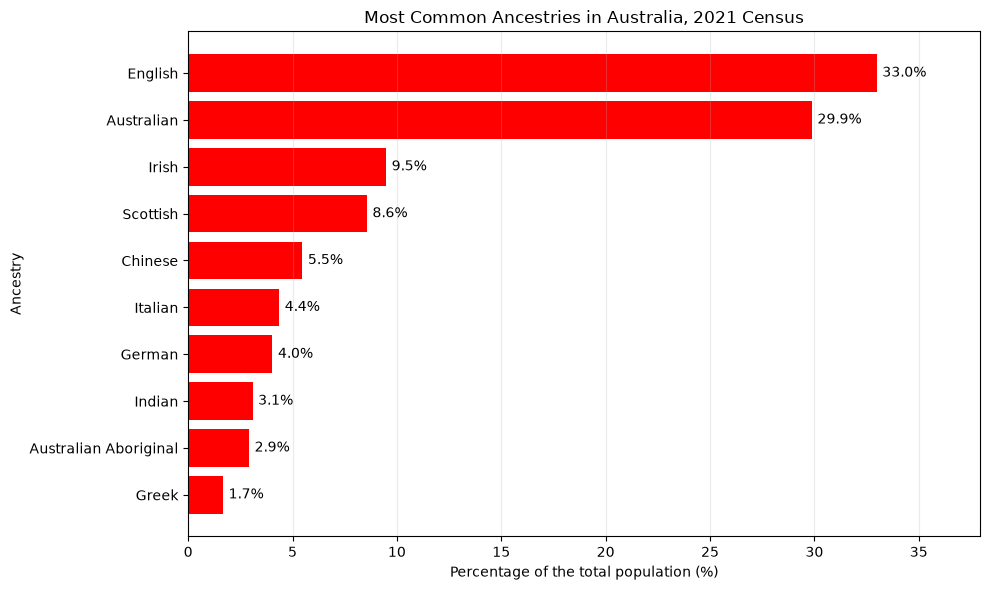

In [15]:
# Plot the ten most reported ancestry categories
ancestry_plot = aus_ancestry_profile.sort_values("Percentage")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    ancestry_plot["Ancestry"],
    ancestry_plot["Percentage"],
    color= 'red'
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in ancestry_plot["Percentage"]
    ],
    padding=4,
    fontsize=10
)

ax.set_title(
    "Most Common Ancestries in Australia, 2021 Census"
)
ax.set_xlabel(
    "Percentage of the total population (%)"
)
ax.set_ylabel("Ancestry")
ax.set_xlim(0, ancestry_plot["Percentage"].max() * 1.15)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()
# Ancestry is a multiple-response variable, so the percentages may add to more than 100%


## Interpretation

English and Australian were the most commonly reported ancestries in Australia, at 33.0% and 29.9%. Irish and Scottish were also common, at 9.5% and 8.6%. Chinese ancestry accounted for 5.5%, while Indian ancestry accounted for 3.1%.

The results show that Australia has people from a range of cultural backgrounds. British and European ancestries were the most common, but Asian and Australian Aboriginal ancestries were also present.

**Note:** People could report more than one ancestry in the Census. Therefore, the percentages may add up to more than 100%.

## Languages Used at Home in Australia

In [16]:
# Load the parts containing total-person language data
aus_language_tables = [
    pd.read_csv("2021Census_G13C_AUS_AUS.csv", na_values=[".."]),
    pd.read_csv("2021Census_G13D_AUS_AUS.csv", na_values=[".."]),
    pd.read_csv("2021Census_G13E_AUS_AUS.csv", na_values=[".."])
]

# Find a variable across the three files
def get_language_value(column_name):
    for table in aus_language_tables:
        if column_name in table.columns:
            return pd.to_numeric(
                table.loc[0, column_name],
                errors="coerce"
            )
    raise KeyError(f"Column not found: {column_name}")


# Ten most commonly used non-English languages
language_columns = {
    "Mandarin": "POL_CL_Mandarin_Tot",
    "Arabic": "POL_Arabic_Tot",
    "Vietnamese": "POL_Vietnamese_Tot",
    "Cantonese": "POL_CL_Canton_Tot",
    "Punjabi": "POL_IAL_Punjabi_Tot",
    "Greek": "POL_Greek_Tot",
    "Italian": "POL_Italian_Tot",
    "Hindi": "POL_IAL_Hindi_Tot",
    "Spanish": "POL_Spanish_Tot",
    "Nepali": "POL_IAL_Nepali_Tot"
}

aus_language_profile = pd.DataFrame({
    "Language": language_columns.keys(),
    "Count": [
        get_language_value(column)
        for column in language_columns.values()
    ]
})

aus_total_population = pd.to_numeric(
    aus_ancestry.loc[0, "Tot_P_Tot_resp"]
)

# Calculate language percentages using Australia's total population
aus_language_profile["Percentage"] = (
    aus_language_profile["Count"]
    / aus_total_population
    * 100
)

aus_language_profile = aus_language_profile.sort_values(
    "Percentage",
    ascending=False
).reset_index(drop=True)


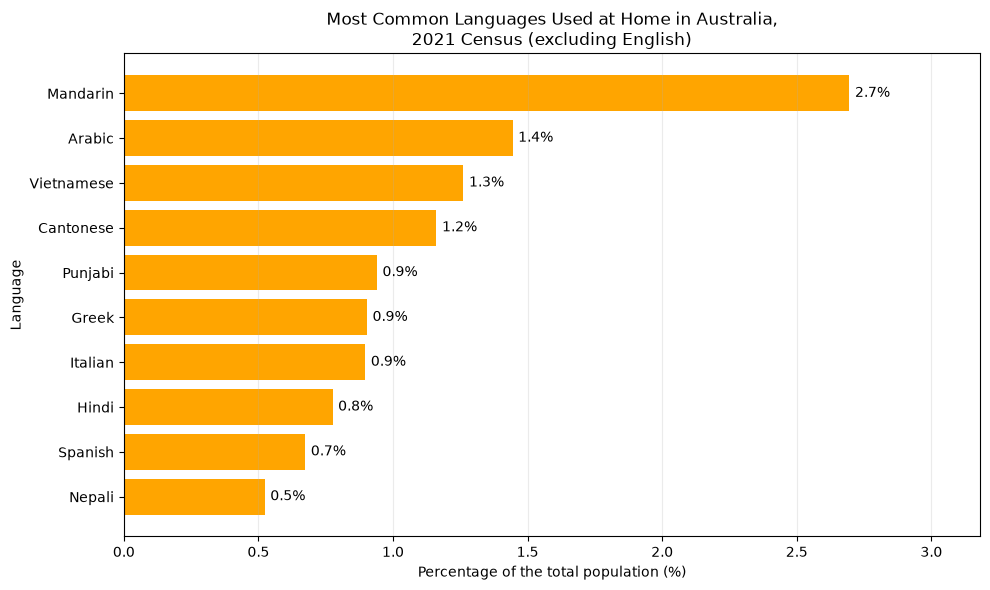

In [17]:
# Plot the ten most common non-English languages used at home
language_plot = aus_language_profile.sort_values("Percentage")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    language_plot["Language"],
    language_plot["Percentage"],
    color= 'orange'
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in language_plot["Percentage"]
    ],
    padding=4,
    fontsize=10
)

ax.set_title(
    "Most Common Languages Used at Home in Australia,\n"
    "2021 Census (excluding English)"
)
ax.set_xlabel("Percentage of the total population (%)")
ax.set_ylabel("Language")
ax.set_xlim(0, language_plot["Percentage"].max() * 1.18)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


## Interpretation

Mandarin was the most common language used at home other than English in Australia, at 2.7% of the population. Arabic, Vietnamese, and Cantonese followed at 1.4%, 1.3% and 1.2%, respectively. Punjabi, Greek, and Italian each accounted for about 0.9%.

The range of languages shown in the graph reflects the cultural diversity of Australia's population. Asian, European, and Middle Eastern languages were all among the most commonly used languages at home.

# Linking Migration and Cultural Diversity

The following two analyses connect migration background with language or ancestry. They provide the main link between the two parts of the research question.

## Birthplace composition of language groups in New Zealand

In [18]:
# Keep ten languages shown in the previous chart
top_language_order = nz_language_profile.head(10)["Language"].tolist()

# Obtain the number of New Zealand-born and overseas-born individuals for each language
language_birthplace = (
    nz_language_raw[
        nz_language_raw["Language"].isin(top_language_order)
        & nz_language_raw["Birthplace"].isin(["NZ born", "Overseas born"])
    ]
    .pivot(
        index="Language",
        columns="Birthplace",
        values="OBS_VALUE"
    )
    .reindex(top_language_order)
)

# Calculate the proportion by place of birth within each language group
language_birthplace["Known birthplace"] = (
    language_birthplace["NZ born"]
    + language_birthplace["Overseas born"]
)

language_birthplace["NZ born (%)"] = (
    language_birthplace["NZ born"]
    / language_birthplace["Known birthplace"]
    * 100
)

language_birthplace["Overseas born (%)"] = (
    language_birthplace["Overseas born"]
    / language_birthplace["Known birthplace"]
    * 100
)


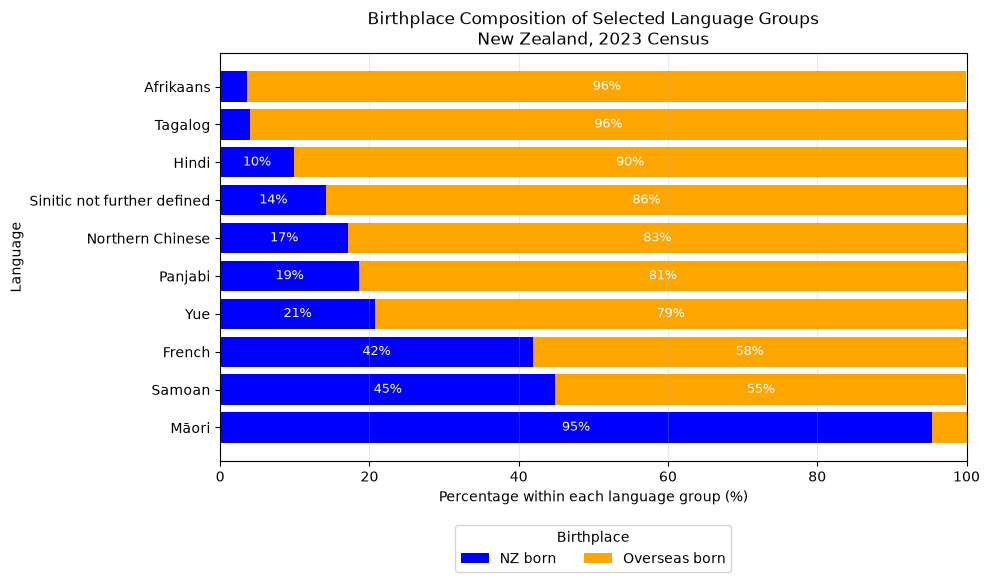

In [19]:
# Compare the NZ-born and overseas-born shares within each language group
birthplace_plot = language_birthplace.sort_values(
    "Overseas born (%)"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    birthplace_plot.index,
    birthplace_plot["NZ born (%)"],
    label="NZ born",
    color= 'blue'
)

ax.barh(
    birthplace_plot.index,
    birthplace_plot["Overseas born (%)"],
    left=birthplace_plot["NZ born (%)"],
    label="Overseas born",
    color= 'orange'
)

# Add percentage labels only when the bar segment is large enough
for container in ax.containers:
    labels = [
        f"{value:.0f}%" if value >= 5 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9
    )

ax.set_title(
    "Birthplace Composition of Selected Language Groups\n"
    "New Zealand, 2023 Census"
)
ax.set_xlabel("Percentage within each language group (%)")
ax.set_ylabel("Language")
ax.set_xlim(0, 100)
ax.legend(
    title="Birthplace",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2
)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


## Interpretation

Birthplace was different across the language groups. Around 95% of Māori speakers were born in New Zealand. In comparison, about 96% of Tagalog and Afrikaans speakers were born overseas. The overseas-born percentage was also high for Hindi (90%), Northern Chinese (83%), and Panjabi speakers (81%). Samoan speakers were more evenly divided, with 45% born in New Zealand and 55% born overseas.

This suggests that birthplace and language are related in New Zealand. However, the results only show a relationship. They do not prove that migration directly causes language diversity.

## Parents' birthplace within ancestry groups in Australia

In [20]:
# Columns describing parents' birthplace for each ancestry
ancestry_parent_columns = {
    "English": {
        "overseas": [
            "English_BP_B_OS",
            "English_FO_B_OS",
            "English_MO_B_OS"
        ],
        "australia": "English_BP_B_Aus"
    },
    "Australian": {
        "overseas": [
            "Aust_BP_B_OS",
            "Aust_FO_B_OS",
            "Aust_MO_B_OS"
        ],
        "australia": "Aust_Both_parents_born_Aust"
    },
    "Irish": {
        "overseas": [
            "Irish_BP_B_OS",
            "Irish_FO_B_OS",
            "Irish_MO_B_OS"
        ],
        "australia": "Irish_BP_B_Aus"
    },
    "Scottish": {
        "overseas": [
            "Scottish_BP_B_OS",
            "Scottish_FO_B_OS",
            "Scottish_MO_B_OS"
        ],
        "australia": "Scottish_BP_B_Aus"
    },
    "Chinese": {
        "overseas": [
            "Chinese_BP_B_OS",
            "Chinese_FO_B_OS",
            "Chinese_MO_B_OS"
        ],
        "australia": "Chinese_BP_B_Aus"
    },
    "Italian": {
        "overseas": [
            "Italian_BP_B_OS",
            "Italian_FO_B_OS",
            "Italian_MO_B_OS"
        ],
        "australia": "Italian_BP_B_Aus"
    },
    "German": {
        "overseas": [
            "German_BP_B_OS",
            "German_FO_B_OS",
            "German_MO_B_OS"
        ],
        "australia": "German_BP_B_Aus"
    },
    "Indian": {
        "overseas": [
            "Indian_BP_B_OS",
            "Indian_FO_B_OS",
            "Indian_MO_B_OS"
        ],
        "australia": "Indian_BP_B_Aus"
    },
    "Australian Aboriginal": {
        "overseas": [
            "Aust_Abor_BP_B_OS",
            "Aust_Abor_FO_B_OS",
            "Aust_Abor_MO_B_OS"
        ],
        "australia": "Aust_Abor_BP_B_Aus"
    },
    "Greek": {
        "overseas": [
            "Greek_BP_B_OS",
            "Greek_FO_B_OS",
            "Greek_MO_B_OS"
        ],
        "australia": "Greek_BP_B_Aus"
    }
}

parent_rows = []

for ancestry, columns in ancestry_parent_columns.items():
    at_least_one_overseas = sum(
        pd.to_numeric(aus_ancestry.loc[0, column])
        for column in columns["overseas"]
    )

    both_australia = pd.to_numeric(
        aus_ancestry.loc[0, columns["australia"]]
    )

    known_parent_birthplace = (
        at_least_one_overseas + both_australia
    )

    parent_rows.append({
        "Ancestry": ancestry,
        "At least one parent born overseas (%)":
            at_least_one_overseas / known_parent_birthplace * 100,
        "Both parents born in Australia (%)":
            both_australia / known_parent_birthplace * 100
    })

aus_ancestry_parents = pd.DataFrame(parent_rows)


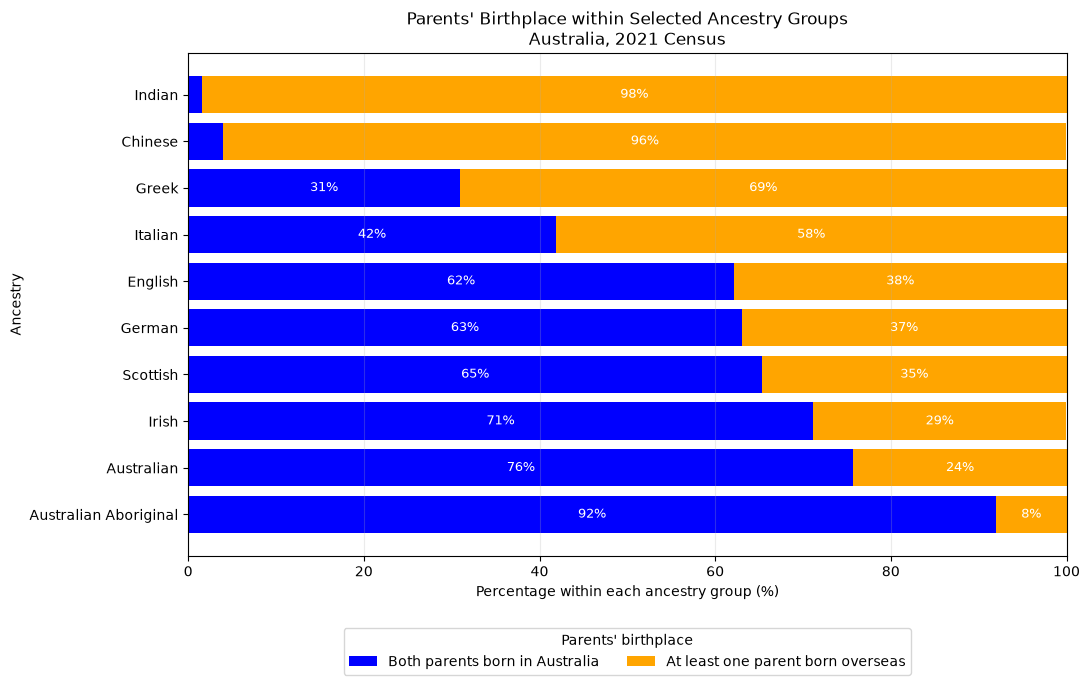

In [21]:
# Compare parental migration background across the selected ancestry groups
parent_plot = aus_ancestry_parents.sort_values(
    "At least one parent born overseas (%)"
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    parent_plot["Ancestry"],
    parent_plot["Both parents born in Australia (%)"],
    label="Both parents born in Australia",
    color= 'blue'
)

ax.barh(
    parent_plot["Ancestry"],
    parent_plot["At least one parent born overseas (%)"],
    left=parent_plot["Both parents born in Australia (%)"],
    label="At least one parent born overseas",
    color= 'orange'
)

for container in ax.containers:
    labels = [
        f"{value:.0f}%" if value >= 5 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9
    )

ax.set_title(
    "Parents' Birthplace within Selected Ancestry Groups\n"
    "Australia, 2021 Census"
)
ax.set_xlabel("Percentage within each ancestry group (%)")
ax.set_ylabel("Ancestry")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.25)

ax.legend(
    title="Parents' birthplace",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2
)

plt.tight_layout()
plt.show()


## Interpretation

Indian and Chinese ancestry groups had the highest percentages of people with at least one parent born overseas, at 98% and 96%. The percentages were also high for Greek (69%) and Italian ancestry (58%).

In comparison, 92% of people with Australian Aboriginal ancestry had both parents born in Australia. This percentage was 76% for Australian ancestry.

These results suggest that ancestry and migration background are related in Australia. However, this graph shows the birthplace of the respondent's parents, not the birthplace of the respondent.

# Comparison and Discussion

Australia and New Zealand had similar overseas-born shares among people with a stated birthplace. They also shared several major overseas birthplace groups, especially England, India and China. Their regional patterns differed: Pacific countries were more prominent in New Zealand's top groups, while Vietnam and Malaysia appeared in Australia's top ten.

The cultural results show that migration background and cultural diversity are related. In New Zealand, most Tagalog, Afrikaans, Hindi and Northern Chinese speakers were born overseas, while most Māori speakers were born in New Zealand. In Australia, Indian and Chinese ancestry groups had high percentages of people with at least one parent born overseas. Australian Aboriginal ancestry was mainly associated with both parents being born in Australia.

The countries cannot be compared using every percentage directly. Australia reports ancestry and language used at home, while New Zealand reports ethnicity and languages spoken. These measures describe related but different ideas.

# Limitations

- Australia used 2021 Census data, while New Zealand used 2023 Census data.
- Birthplace does not show citizenship, migration category or reason for migration.
- The Australian linkage uses parents' birthplace, while the New Zealand linkage uses the respondent's birthplace.
- Ancestry, ethnicity and language can allow multiple responses.
- The analysis uses national totals and does not show regional differences within each country.
- The findings show associations and do not prove that migration causes cultural diversity.

# Conclusion

Both countries had culturally diverse populations and substantial overseas-born shares. Their broad migration profiles were similar, but the main source countries and cultural groups differed. The language and ancestry results also showed a clear relationship with migration background. Migrant-linked language and ancestry groups were more likely to have an overseas birthplace or overseas-born parents, while Indigenous cultural groups were more strongly connected with local birthplace. Overall, migration is an important part of the cultural diversity observed in both Census datasets, although the different variables and Census years limit direct comparison.